In [86]:
# Objective:
# Analyze the risk-return profile of a diversified portfolio
# using real market data and evaluate the impact of correlation.

In [37]:
# Selección de activos:
# AAPL y MSFT → sector tecnológico
# XOM → energía
# GLD → oro (activo defensivo)
# SPY → índice del mercado (benchmark)

import yfinance as yf
import numpy as np
import pandas as pd

tickers = ["AAPL", "MSFT", "XOM", "GLD", "SPY"]

In [38]:
data = yf.download(tickers, start="2020-01-01", end="2026-01-01") # Descarga de precios históricos
print(data.columns) # Se inspeccionan las columnas para identificar la estructura de los datos

[*********************100%***********************]  5 of 5 completed

MultiIndex([( 'Close', 'AAPL'),
            ( 'Close',  'GLD'),
            ( 'Close', 'MSFT'),
            ( 'Close',  'SPY'),
            ( 'Close',  'XOM'),
            (  'High', 'AAPL'),
            (  'High',  'GLD'),
            (  'High', 'MSFT'),
            (  'High',  'SPY'),
            (  'High',  'XOM'),
            (   'Low', 'AAPL'),
            (   'Low',  'GLD'),
            (   'Low', 'MSFT'),
            (   'Low',  'SPY'),
            (   'Low',  'XOM'),
            (  'Open', 'AAPL'),
            (  'Open',  'GLD'),
            (  'Open', 'MSFT'),
            (  'Open',  'SPY'),
            (  'Open',  'XOM'),
            ('Volume', 'AAPL'),
            ('Volume',  'GLD'),
            ('Volume', 'MSFT'),
            ('Volume',  'SPY'),
            ('Volume',  'XOM')],
           names=['Price', 'Ticker'])


In [39]:
# Se seleccionan precios de cierre (Close) para el análisis
# Nota: idealmente se usaría "Adj Close", pero en algunos casos no está disponible

precios = data["Close"]
precios

Ticker,AAPL,GLD,MSFT,SPY,XOM
Date,,,,,
2020-01-02,72.400528,143.949997,152.158401,296.888245,53.306408
2020-01-03,71.696632,145.860001,150.263733,294.640076,52.877857
2020-01-06,72.267952,147.389999,150.652130,295.764130,53.283859
2020-01-07,71.928062,147.970001,149.278519,294.932495,52.847775
2020-01-08,73.085098,146.860001,151.656326,296.504333,52.050808
...,...,...,...,...,...
2025-12-24,273.554016,411.929993,486.908630,688.499695,118.430618
2025-12-26,273.144409,416.739990,486.599365,688.429871,118.321342
2025-12-29,273.504089,398.600006,485.990753,685.976562,119.731941


In [40]:
# Verificación de datos faltantes en precios
print(precios.isnull().sum())

# Se analiza tanto el número absoluto como el porcentaje
print(precios.isnull().mean() * 100)

Ticker
AAPL    0
GLD     0
MSFT    0
SPY     0
XOM     0
dtype: int64
Ticker
AAPL    0.0
GLD     0.0
MSFT    0.0
SPY     0.0
XOM     0.0
dtype: float64


In [41]:
# Cálculo de rendimientos porcentuales diarios
# Se utiliza pct_change() para transformar precios en retornos
rendimientos = precios.pct_change()

In [42]:
rendimientos

Ticker,AAPL,GLD,MSFT,SPY,XOM
Date,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN
2020-01-03,-0.009722,0.013269,-0.012452,-0.007572,-0.008039
2020-01-06,0.007969,0.010490,0.002585,0.003815,0.007678
2020-01-07,-0.004703,0.003935,-0.009118,-0.002812,-0.008184
2020-01-08,0.016086,-0.007502,0.015929,0.005329,-0.015080
...,...,...,...,...,...
2025-12-24,0.005324,-0.004134,0.002403,0.003518,-0.001675
2025-12-26,-0.001497,0.011677,-0.000635,-0.000101,-0.000923
2025-12-29,0.001317,-0.043528,-0.001251,-0.003564,0.011922


In [43]:
# Eliminación de valores NaN generados por el cálculo de rendimientos
rendimientos = rendimientos.dropna()

In [44]:
rendimientos.head()

Ticker,AAPL,GLD,MSFT,SPY,XOM
Date,,,,,
2020-01-03,-0.009722,0.013269,-0.012452,-0.007572,-0.008039
2020-01-06,0.007969,0.010490,0.002585,0.003815,0.007678
2020-01-07,-0.004703,0.003935,-0.009118,-0.002812,-0.008184
2020-01-08,0.016086,-0.007502,0.015929,0.005329,-0.015080
2020-01-09,0.021241,-0.005652,0.012493,0.006781,0.007656


In [46]:
rendimientos.shape

(1507, 5)

In [47]:
# Retorno promedio diario (esperado)
rendimientos.mean()

Ticker
AAPL    0.001078
GLD     0.000725
MSFT    0.000939
SPY     0.000636
XOM     0.000750
dtype: float64

In [48]:
# Volatilidad (riesgo)
rendimientos.std()

Ticker
AAPL    0.020038
GLD     0.010295
MSFT    0.018613
SPY     0.013070
XOM     0.020667
dtype: float64

In [49]:
# Correlación entre activos
rendimientos.corr()

Ticker,AAPL,GLD,MSFT,SPY,XOM
Ticker,,,,,
AAPL,1.000000,0.103276,0.709151,0.783912,0.291231
GLD,0.103276,1.000000,0.092170,0.131937,0.082316
MSFT,0.709151,0.092170,1.000000,0.803279,0.236028
SPY,0.783912,0.131937,0.803279,1.000000,0.505069
XOM,0.291231,0.082316,0.236028,0.505069,1.000000


In [51]:
pesos = np.array([0.2, 0.2, 0.2, 0.2, 0.2]) # Construcción de portafolio con pesos iguales (20% cada activo)
portafolio = rendimientos.values @ pesos # Se utiliza multiplicación matricial para obtener el rendimiento del portafolio

In [52]:
# Volatilidad del portafolio
np.std(portafolio)

np.float64(0.012040061736528234)

In [53]:
# Retorno promedio del portafolio
np.mean(portafolio)

np.float64(0.0008255178248308487)

In [54]:
# El portafolio diversificado reduce la volatilidad en comparación
# con los activos individuales, evidenciando los beneficios de la diversificación.
#
# La inclusión de activos como GLD (baja correlación) y XOM (diversificación sectorial)
# permite mitigar el riesgo sin eliminar completamente el potencial de retorno.
#
# Aunque el portafolio no maximiza el rendimiento, sí mejora el equilibrio
# riesgo-retorno, lo que lo convierte en una estrategia más robusta.

In [55]:
import matplotlib.pyplot as plt

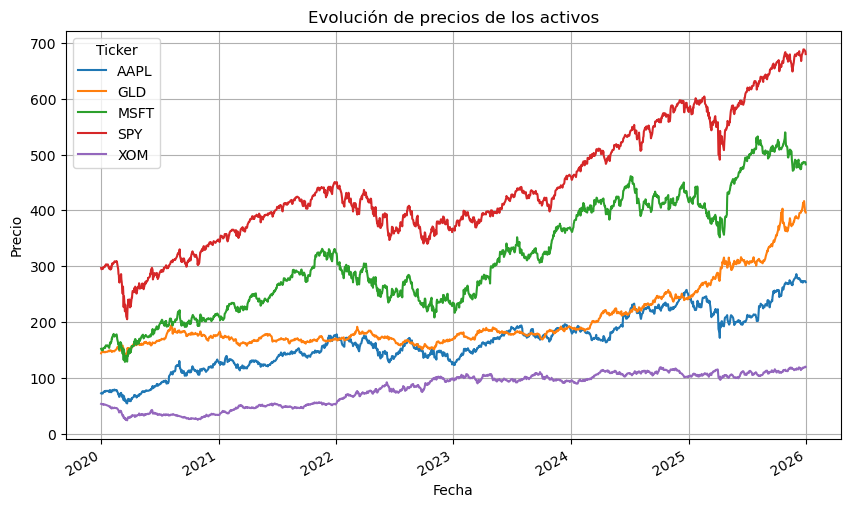

In [61]:
precios.plot(figsize=(10,6))
plt.title("Evolución de precios de los activos")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.grid()
plt.show()

In [62]:
# Insight:
# Se observa un crecimiento sostenido en los activos tecnológicos,
# mientras que GLD presenta un comportamiento más estable.
# SPY refleja el comportamiento general del mercado.

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

In [65]:
plt.figure(figsize=(8,6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

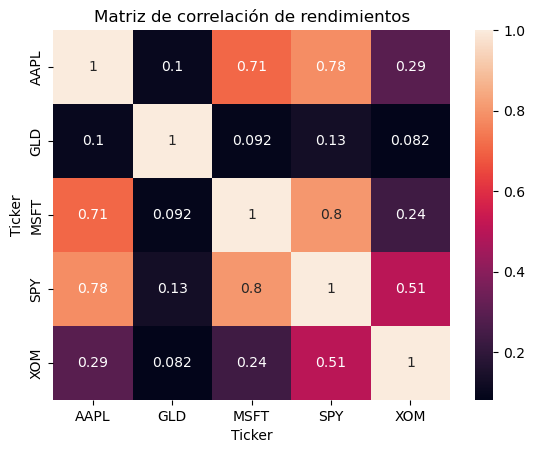

In [67]:
sns.heatmap(rendimientos.corr(), annot=True)
plt.title("Matriz de correlación de rendimientos")
plt.show()

In [68]:
# Insight:
# Los activos tecnológicos presentan alta correlación entre sí,
# lo que limita los beneficios de diversificación.
#
# GLD muestra baja correlación con el resto del portafolio,
# actuando como un activo defensivo que reduce el riesgo total.

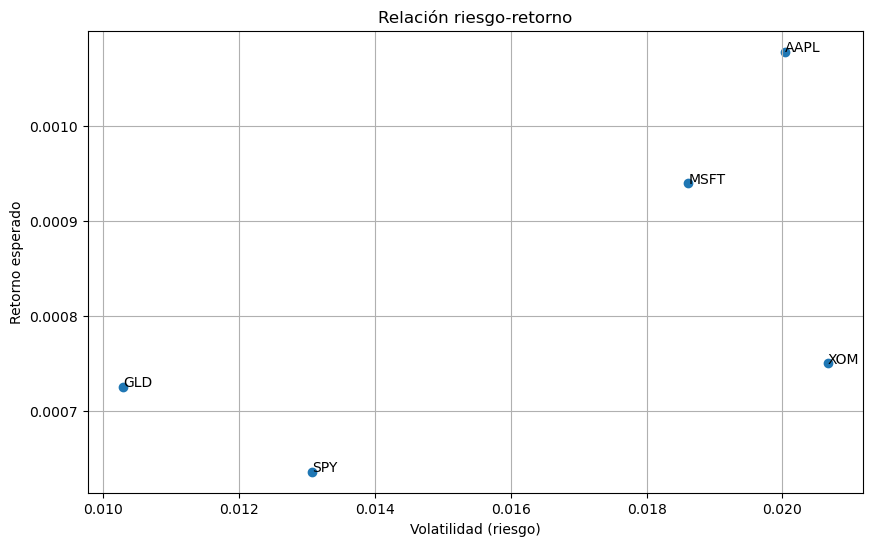

In [80]:
retornos = rendimientos.mean()
volatilidad = rendimientos.std()

plt.figure(figsize=(10,6))
plt.scatter(volatilidad, retornos)

for i in retornos.index:
    plt.text(volatilidad[i], retornos[i], i)

plt.xlabel("Volatilidad (riesgo)")
plt.ylabel("Retorno esperado")
plt.title("Relación riesgo-retorno")
plt.grid()
plt.show()

In [81]:
# Insight:
# Los activos tecnológicos presentan mayores retornos acompañados de mayor volatilidad,
# reflejando el clásico trade-off riesgo-retorno.
#
# GLD se posiciona como un activo defensivo con menor volatilidad,
# lo que contribuye a la estabilidad del portafolio.

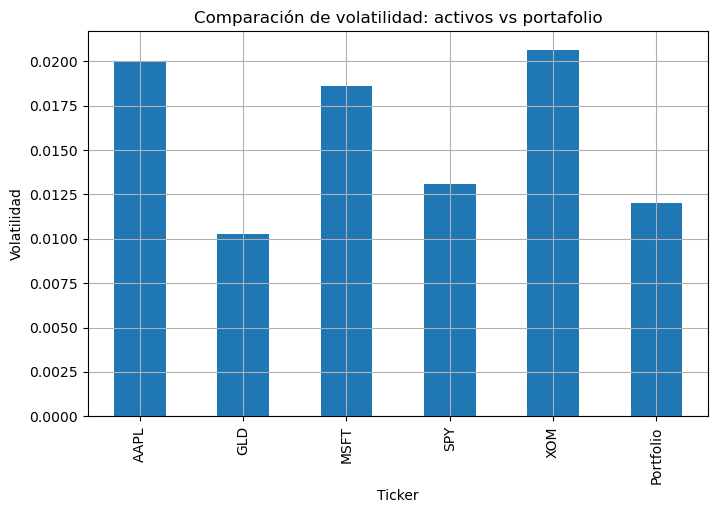

In [84]:
volatilidades = rendimientos.std()
volatilidades["Portfolio"] = np.std(portafolio)

volatilidades.plot(kind="bar", figsize=(8,5))
plt.title("Comparación de volatilidad: activos vs portafolio")
plt.ylabel("Volatilidad")
plt.grid()
plt.show()

In [85]:
# Insight:
# El portafolio presenta una volatilidad inferior a la de varios activos individuales,
# lo que evidencia los beneficios de la diversificación.
#
# La combinación de activos con diferentes niveles de correlación permite
# reducir el riesgo total sin eliminar completamente el retorno esperado.